In [8]:
import glob,os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [10]:
# =========================
# 1️⃣ Load the SWC file
# =========================
def load_swc(path):
    return pd.read_csv(
        path,
        comment='#',
        sep=r'\s+',
        names=['id', 'type', 'x', 'y', 'z', 'r', 'parent']
    )


# =========================
# 2️⃣ Get the soma coordinates (3D, robust)
# =========================
def get_soma_3d(df):
    soma_nodes = df[df['type'] == 1]

    if len(soma_nodes) >= 2:
        raise ValueError("More than one soma (type=1) found in SWC")

    # Use the mean coordinates of multiple soma points for greater stability
    return soma_nodes[['x', 'y', 'z']].mean().values


# =========================
# 3️⃣ Convert the SWC structure to edges (3D)
# =========================
def swc_to_edges_3d(df):
    dendrite = df[df["type"].isin([3])]

    segments = []
    for _, row in dendrite.iterrows():
        if row.parent == -1:
            continue

        parent = df[df["id"] == row.parent]
        if parent.empty:
            continue

        p1 = np.array([row.x, row.y, row.z])
        p2 = parent[["x", "y", "z"]].values[0]

        segments.append((p1, p2))

    return segments


# =========================
# 4️⃣ Calculate line segment–sphere intersections (3D, robust)
# =========================
def segment_sphere_intersections(p1, p2, center, radius, eps=1e-6):

    p1 = np.asarray(p1)
    p2 = np.asarray(p2)
    c = np.asarray(center)

    d = p2 - p1
    f = p1 - c

    a = np.dot(d, d)
    b = 2 * np.dot(d, f)
    c_coef = np.dot(f, f) - radius**2

    disc = b * b - 4 * a * c_coef

    # Handle floating-point errors
    if disc < -eps:
        return []

    disc = max(disc, 0.0)
    sqrt_disc = np.sqrt(disc)

    t1 = (-b - sqrt_disc) / (2 * a)
    t2 = (-b + sqrt_disc) / (2 * a)

    pts = []
    for t in (t1, t2):
        if 0 <= t <= 1:
            pts.append(p1 + t * d)

    return pts


# =========================
# 5️⃣ Calculate the Sholl profile (core function)
# =========================
def sholl_3d_profile(df, step=10, max_radius=None):

    soma = get_soma_3d(df)
    edges = swc_to_edges_3d(df)

    dendrite = df[df["type"].isin([3])]

    # Automatically determine the maximum radius
    if max_radius is None:
        coords = dendrite[['x', 'y', 'z']].values
        dists = np.linalg.norm(coords - soma, axis=1)
        max_radius = np.max(dists)

    # Optional: exclude potential noise near the outer boundary
    max_radius = max_radius * 0.95

    radii = np.arange(step, max_radius, step)

    counts = []

    for r in radii:

        crossing_count = 0

        for p1, p2 in edges:
            pts = segment_sphere_intersections(p1, p2, soma, r)

            # Count each segment once if it crosses the sphere
            if len(pts) > 0:
                crossing_count += 1

        counts.append(crossing_count)

    return radii, np.array(counts)


# =========================
# 6️⃣ Plot the Sholl curve
# =========================
def plot_sholl_curve(radii, counts, name):

    plt.figure(figsize=(6, 5))

    plt.plot(radii, counts, marker='o')

    plt.xlabel("Radius (µm)")
    plt.ylabel("Sholl intersections")
    plt.title("%s 3D Sholl analysis" % name)

    plt.tight_layout()
    plt.savefig("%s 3D Sholl analysis.jpg" % name, dpi=300)
    plt.close()


# =========================
# 7️⃣ Integrated analysis pipeline
# =========================
def run_sholl(swc_path, step=10, name=""):

    df = load_swc(swc_path)

    radii, counts = sholl_3d_profile(df, step=step)

    plot_sholl_curve(radii, counts, name=name)

    return radii, counts


# =========================
# 8️⃣ Example usage
# =========================
# radii, counts = run_sholl("your_neuron.swc", step=10)

In [12]:


swcs = glob.glob("..\\data\\swc\\*")
savepath = ".\\soma_sholl"
os.makedirs(savepath,exist_ok=True)


In [ ]:
for swc in tqdm(swcs):
    neuron = swc.split("\\")[-1][0:-4]
    try:
        radii, counts = run_sholl(swc, step=10,name = neuron)

        dftmp = pd.DataFrame(counts,index=radii,columns = [neuron])
        dftmp.to_csv(".\\soma_sholl\\%s.csv"%neuron)
    except:
        print(neuron)


100%|██████████| 38/38 [00:45<00:00,  1.19s/it]


In [14]:
files = glob.glob(r".\\soma_sholl\*.csv")
dfall = pd.DataFrame()
for file in files:
    # print(file)
    df = pd.read_csv(file,index_col=0)
    dfall = pd.concat([dfall,df],axis=1)
dfall = dfall.fillna(0).T
dfall.to_csv(".\\all_neurons_sholl.csv")

In [15]:
dfall

,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0,100.0,...,910.0,920.0,930.0,940.0,950.0,960.0,970.0,980.0,990.0,1000.0
221058_038_Sst,6.0,12.0,16.0,17.0,19.0,18.0,15.0,15.0,13.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221058_040_Sst,6.0,5.0,6.0,6.0,8.0,9.0,10.0,10.0,11.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221058_071_Sst,7.0,6.0,6.0,8.0,9.0,12.0,11.0,11.0,12.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221058_088_Sst,2.0,4.0,5.0,5.0,7.0,7.0,8.0,9.0,9.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221058_104_Sst,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221058_107_Sst,3.0,4.0,8.0,8.0,9.0,10.0,12.0,14.0,14.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221058_113_Sst,7.0,3.0,3.0,6.0,7.0,8.0,10.0,15.0,17.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221297_036_Sst,7.0,8.0,14.0,15.0,16.0,17.0,18.0,17.0,18.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221297_037_Sst,5.0,9.0,12.0,16.0,18.0,21.0,18.0,17.0,15.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221297_038_Sst,2.0,9.0,16.0,18.0,19.0,21.0,22.0,21.0,18.0,16.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
dfall["0.0"] = 0
dfall["cluster"] = [item.split("_")[-1] for item in dfall.index.tolist()]
dfall = dfall.reset_index()

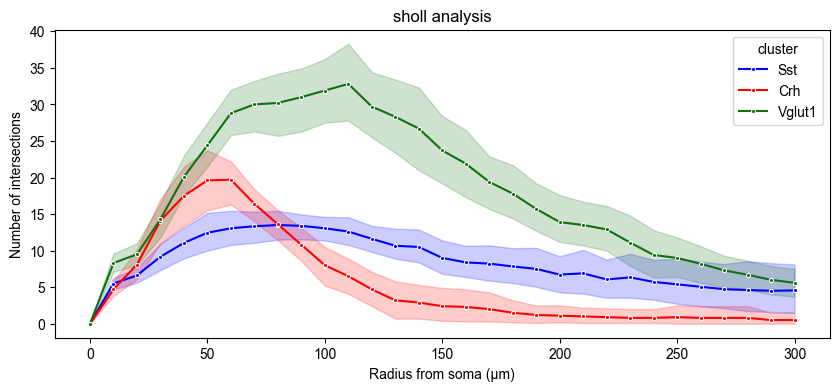

In [20]:
df_long = dfall.melt(
    id_vars=['index', 'cluster'],  # 保留 sample 和 cluster
    var_name='x',                  # 原来的 10,20,30 → x
    value_name='value'             # 数值
)
df_long["x"] = pd.to_numeric(df_long["x"])
df_long2 = df_long.loc[df_long.x<=300]
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

plt.figure(figsize=(10,4))

dic_list = {"Vglut1":'#107010',"Sst":'#0000ff',"Crh":'red'}

sns.lineplot(
    data=df_long2,
    x='x',          # 横轴
    y='value',      # 纵轴
    hue='cluster',  # 按 cluster 分组
    marker='.',
    palette = dic_list
)

plt.ylabel("Number of intersections")
plt.xlabel("Radius from soma (µm)")
plt.title('sholl analysis')
plt.savefig("sholl analysis_geno_base.pdf",dpi=300)
plt.savefig("sholl analysis_geno_base.jpg",dpi=300)